In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

In [ ]:
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['HouseVal'] = data.target
print(df[:5])

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  HouseVal  
0    -122.23     4.526  
1    -122.22     3.585  
2    -122.24     3.521  
3    -122.25     3.413  
4    -122.25     3.422  


In [ ]:
X = df.drop('HouseVal', axis=1)
y = df['HouseVal']
print(X[:5])
print(y[:5])

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: HouseVal, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512, 8)
(4128, 8)
(16512,)
(4128,)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [ ]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [ ]:
sample_data = X_test_scaled[0].reshape(1, -1)
lr_pred = lr.predict(sample_data)
ridge_pred = ridge.predict(sample_data)
lasso_pred = lasso.predict(sample_data)
print("Sample Prediction:")
print("Linear:", lr_pred[0])
print("Ridge:",  ridge_pred[0])
print("Lasso:",   lasso_pred[0])

Sample Prediction:
Linear: 0.7191228416019151
Ridge: 0.7194722372939968
Lasso: 1.2184288200131896


In [ ]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
print("Mean Squared Error (MSE):")
print("Linear:", mean_squared_error(y_test, y_pred_lr))
print("Ridge:", mean_squared_error(y_test, y_pred_ridge))
print("Lasso:", mean_squared_error(y_test, y_pred_lasso))

Mean Squared Error (MSE):
Linear: 0.5558915986952441
Ridge: 0.5558548589435971
Lasso: 0.6796290284328824


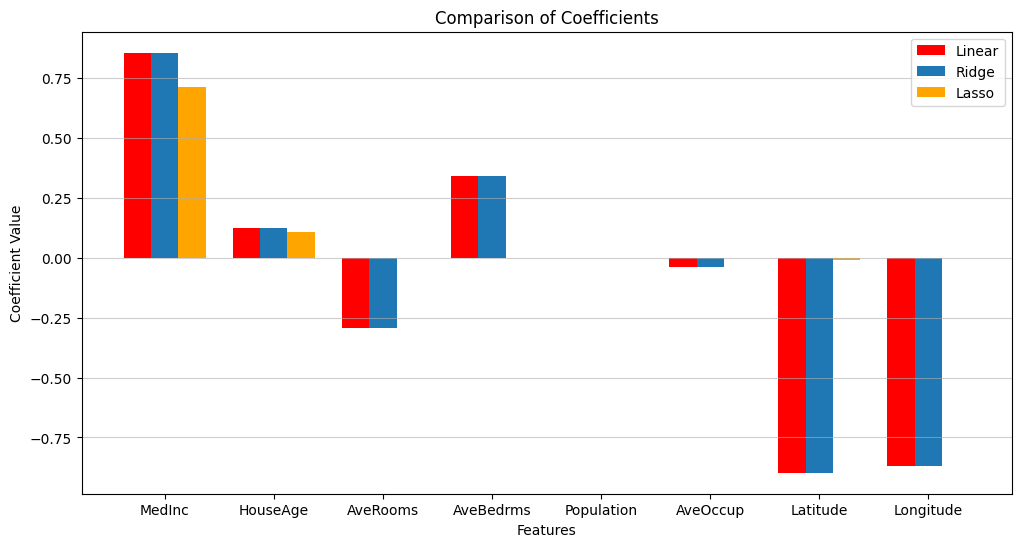

In [ ]:
x = np.arange(len(data.feature_names))
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - 0.25, lr.coef_, 0.25, label='Linear', color='red')
ax.bar(x, ridge.coef_, 0.25, label='Ridge')
ax.bar(x + 0.25, lasso.coef_, 0.25, label='Lasso', color='orange')
ax.set_title('Comparison of Coefficients')
ax.set_xlabel('Features')
ax.set_ylabel('Coefficient Value')
ax.set_xticks(x)
ax.set_xticklabels(data.feature_names)
ax.grid(True, axis='y', alpha=0.6)
ax.legend()
plt.show()

Lasso and ridge regularization:
1. Import all necessary libraries.
2. Load the california housing dataset.
3. Split the features into X and y.
4. Standardize the datasets.
5. Train linear regression, ridge and lasso regularized models.
6. Perform predictions using the models.
7. Compute the mean squared error.
8. Plot the graph to visualize the coefficients.